In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")

from src.database.connection import get_connection

import warnings
warnings.filterwarnings(
    "ignore",
    message = "pandas only supports SQLAlchemy connectable.*",
    category = UserWarning
)

#### LOAD DATA

In [2]:
conn = get_connection()

query = """
    SELECT *
    FROM generation_eda
    ORDER BY start_time
"""

generation = pd.read_sql(query, conn)
generation["publish_time"] = pd.to_datetime(generation["publish_time"], utc = True)
generation["start_time"] = pd.to_datetime(generation["start_time"], utc = True)

query = """
    SELECT 
        *
    FROM demand_eda;
"""

demand = pd.read_sql(query, conn)
demand["start_time"] = pd.to_datetime(demand["start_time"], utc = True)

conn.close()

generation.head()

,publish_time,start_time,fuel_type,generation_mw
0,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,BIOMASS,1169.0
1,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,CCGT,4459.0
2,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,COAL,0.0
3,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,INTELEC,644.0
4,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,INTEW,-332.0


In [3]:
generation.describe()

,generation_mw
count,946926.000000
mean,1491.161845
std,3119.915644
min,-2480.000000
25%,0.000000
50%,420.000000
75%,1398.000000
max,27339.000000


In [4]:
generation.groupby("fuel_type")["start_time"].diff().value_counts().sort_index()

start_time
0 days 00:30:00    946890
0 days 01:00:00        18
Name: count, dtype: int64

In [5]:
generation.groupby("fuel_type").agg(rows = ("generation_mw", "size"))

,rows
fuel_type,
BIOMASS,52607
CCGT,52607
COAL,52607
INTELEC,52607
INTEW,52607
INTFR,52607
INTIFA2,52607
INTIRL,52607
INTNED,52607


In [6]:
diffs = generation.groupby("fuel_type")["start_time"].diff()
generation.loc[diffs == pd.Timedelta("1 hour")]

,publish_time,start_time,fuel_type,generation_mw
129726,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,INTELEC,184.0
129727,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,WIND,13064.0
129728,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,PS,-1106.0
129729,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,OTHER,333.0
129730,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,OIL,0.0
129731,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,OCGT,0.0
129732,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,NUCLEAR,5243.0
129733,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,NPSHYD,640.0
129734,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,INTNSL,-1454.0
129735,2023-12-29 04:30:00+00:00,2023-12-29 04:00:00+00:00,INTNEM,-324.0


In [7]:
generation.head()

,publish_time,start_time,fuel_type,generation_mw
0,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,BIOMASS,1169.0
1,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,CCGT,4459.0
2,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,COAL,0.0
3,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,INTELEC,644.0
4,2023-08-01 00:30:00+00:00,2023-08-01 00:00:00+00:00,INTEW,-332.0


In [8]:
fill_generation = generation.copy()

fill_generation = generation.sort_values(["fuel_type", "start_time"])
fill_generation["previous_generation"] = fill_generation.groupby("fuel_type")["generation_mw"].shift(1)
fill_generation["next_generation"] = fill_generation.groupby("fuel_type")["generation_mw"].shift(-1)
fill_generation["previous_start_time"] = fill_generation.groupby("fuel_type")["start_time"].shift(1)
fill_generation["interval"] = fill_generation["start_time"] - fill_generation["previous_start_time"]

wrong_intervals = fill_generation[fill_generation["interval"] == pd.Timedelta(hours = 1)].copy()
wrong_intervals["publish_time"] = wrong_intervals["start_time"]
wrong_intervals["start_time"] = wrong_intervals["start_time"] - pd.Timedelta(minutes = 30)
wrong_intervals["generation_mw"] = ((
    wrong_intervals["previous_generation"] + wrong_intervals["next_generation"]
) / 2).round(0)

wrong_intervals = wrong_intervals[["publish_time", "start_time", "fuel_type", "generation_mw"]]

generation = pd.concat([generation, wrong_intervals], ignore_index = True).sort_values("start_time")

In [9]:
fill_demand = demand.copy()

fill_demand["previous_demand"] = fill_demand["true_demand_mw"].shift(1)
fill_demand["next_demand"] = fill_demand["true_demand_mw"].shift(-1)
fill_demand["previous_start_time"] = fill_demand["start_time"].shift(1)
fill_demand["interval"] = fill_demand["start_time"] - fill_demand["previous_start_time"]

wrong_intervals = fill_demand[fill_demand["interval"] == pd.Timedelta(hours = 1)].copy()
wrong_intervals["start_time"] = wrong_intervals["start_time"] - pd.Timedelta(minutes = 30)
wrong_intervals["true_demand_mw"] = ((
    wrong_intervals["previous_demand"] + wrong_intervals["next_demand"]
) / 2).round(0)

wrong_intervals = wrong_intervals[["start_time", "true_demand_mw"]]

demand = pd.concat([demand, wrong_intervals], ignore_index = True).sort_values("start_time")
demand = demand.rename(columns = {"start_time": "prediction_time"})

In [10]:
generation_pivot = generation.pivot_table(
    index = "publish_time",
    columns = "fuel_type",
    values = "generation_mw",
    aggfunc = "last"
).reset_index().sort_values("publish_time")

generation_pivot.head()

fuel_type,publish_time,BIOMASS,CCGT,COAL,INTELEC,INTEW,INTFR,INTIFA2,INTIRL,INTNED,INTNEM,INTNSL,NPSHYD,NUCLEAR,OCGT,OIL,OTHER,PS,WIND
0,2023-08-01 00:30:00+00:00,1169.0,4459.0,0.0,644.0,-332.0,396.0,598.0,-372.0,-906.0,-154.0,338.0,145.0,2925.0,0.0,0.0,236.0,-306.0,9365.0
1,2023-08-01 01:00:00+00:00,1166.0,4618.0,0.0,646.0,-290.0,384.0,590.0,-372.0,-910.0,-150.0,274.0,146.0,2931.0,0.0,0.0,154.0,-360.0,9389.0
2,2023-08-01 01:30:00+00:00,1164.0,4625.0,0.0,696.0,-378.0,646.0,564.0,-372.0,-1010.0,98.0,20.0,146.0,2929.0,0.0,0.0,153.0,-358.0,9013.0
3,2023-08-01 02:00:00+00:00,1167.0,4337.0,0.0,698.0,-444.0,652.0,560.0,-372.0,-1010.0,102.0,-12.0,146.0,2928.0,0.0,0.0,155.0,-358.0,8960.0
4,2023-08-01 02:30:00+00:00,1169.0,4435.0,0.0,684.0,-480.0,578.0,496.0,-372.0,-1010.0,146.0,-58.0,145.0,2929.0,0.0,0.0,191.0,-492.0,8999.0


In [11]:
modelling = pd.merge_asof(
    left = demand,
    right = generation_pivot,
    left_on = "prediction_time",
    right_on = "publish_time",
    direction = "backward"
)

modelling.iloc[336: 340]

,prediction_time,true_demand_mw,publish_time,BIOMASS,CCGT,COAL,INTELEC,INTEW,INTFR,INTIFA2,...,INTNED,INTNEM,INTNSL,NPSHYD,NUCLEAR,OCGT,OIL,OTHER,PS,WIND
336,2023-08-08 00:00:00+00:00,18379.0,2023-08-08 00:00:00+00:00,742.0,4016.0,0.0,848.0,-522.0,1358.0,740.0,...,950.0,434.0,1198.0,147.0,3320.0,2.0,0.0,154.0,-566.0,6882.0
337,2023-08-08 00:30:00+00:00,18102.0,2023-08-08 00:30:00+00:00,785.0,4136.0,0.0,756.0,-528.0,1220.0,614.0,...,844.0,460.0,1198.0,139.0,3389.0,2.0,0.0,187.0,-616.0,6810.0
338,2023-08-08 01:00:00+00:00,17744.0,2023-08-08 01:00:00+00:00,776.0,4138.0,0.0,760.0,-528.0,1202.0,606.0,...,844.0,460.0,1200.0,137.0,3419.0,2.0,0.0,201.0,-616.0,6505.0
339,2023-08-08 01:30:00+00:00,17493.0,2023-08-08 01:30:00+00:00,783.0,4196.0,0.0,954.0,-528.0,878.0,570.0,...,794.0,294.0,1200.0,118.0,3418.0,2.0,0.0,189.0,-388.0,6287.0


In [12]:
modelling = modelling.drop(index = 0).reset_index(drop = True)

modelling["interval"] = modelling["prediction_time"] - modelling["publish_time"]
modelling["interval"].value_counts()

interval
0 days 00:00:00    52503
0 days 00:30:00       27
0 days 01:00:00       16
0 days 01:30:00       16
0 days 02:00:00       16
0 days 02:30:00       13
0 days 03:00:00        9
0 days 03:30:00        4
0 days 04:00:00        1
0 days 04:30:00        1
0 days 00:27:00        1
Name: count, dtype: int64

In [13]:
wrong_intervals = modelling[modelling["interval"] > pd.Timedelta(0)]
wrong_intervals[["prediction_time", "publish_time", "interval"]].head(20)

,prediction_time,publish_time,interval
2803,2023-09-28 10:00:00+00:00,2023-09-28 09:30:00+00:00,0 days 00:30:00
2804,2023-09-28 10:30:00+00:00,2023-09-28 09:30:00+00:00,0 days 01:00:00
2805,2023-09-28 11:00:00+00:00,2023-09-28 09:30:00+00:00,0 days 01:30:00
2806,2023-09-28 11:30:00+00:00,2023-09-28 09:30:00+00:00,0 days 02:00:00
2807,2023-09-28 12:00:00+00:00,2023-09-28 09:30:00+00:00,0 days 02:30:00
2808,2023-09-28 12:30:00+00:00,2023-09-28 09:30:00+00:00,0 days 03:00:00
2809,2023-09-28 13:00:00+00:00,2023-09-28 09:30:00+00:00,0 days 03:30:00
2810,2023-09-28 13:30:00+00:00,2023-09-28 09:30:00+00:00,0 days 04:00:00
2811,2023-09-28 14:00:00+00:00,2023-09-28 09:30:00+00:00,0 days 04:30:00
3714,2023-10-17 09:30:00+00:00,2023-10-17 09:00:00+00:00,0 days 00:30:00


In [14]:
#https://bscdocs.elexon.co.uk/interface-definition-documents/neta-interface-definition-and-design-document-part-1-interfaces-with-bsc-parties-and-their-agents?utm_source=chatgpt.com
#4.13.4.42 Fuel Type

fuels = [
    "BIOMASS",
    "WIND",
    "PS",
    "OTHER",
    "OIL",
    "OCGT",
    "NPSHYD",
    "NUCLEAR",
    "COAL",
    "CCGT"
]

interconnectors = [
    "INTNSL",
    "INTNEM",
    "INTIRL",
    "INTIFA2",
    "INTFR",
    "INTEW",
    "INTELEC",
    "INTNED"
]

In [15]:
modelling[fuels].describe().T

,count,mean,std,min,25%,50%,75%,max
BIOMASS,52607.0,2133.999848,800.079640,73.0,1419.0,2282.0,2869.0,3415.0
WIND,52607.0,7822.998688,4362.271115,79.0,4133.0,7318.0,11379.5,18439.0
PS,52607.0,-56.582546,617.114335,-2480.0,-294.0,-8.0,222.0,2286.0
OTHER,52607.0,495.238447,394.572956,27.0,233.0,359.0,617.0,4487.0
OIL,52607.0,0.005380,0.580145,0.0,0.0,0.0,0.0,82.0
OCGT,52607.0,20.655521,63.460219,0.0,0.0,1.0,6.0,1114.0
NPSHYD,52607.0,401.447602,232.794385,13.0,212.0,368.0,560.0,1177.0
NUCLEAR,52607.0,4104.575019,771.953403,413.0,3587.0,4146.0,4713.0,5723.0
COAL,52607.0,122.651529,294.187406,0.0,0.0,0.0,0.0,1873.0
CCGT,52607.0,8631.297489,5590.460707,303.0,3919.0,7308.0,12006.5,27339.0


In [16]:
modelling[interconnectors].describe().T

,count,mean,std,min,25%,50%,75%,max
INTNSL,52607.0,939.394073,746.505284,-1454.0,698.0,1396.0,1398.0,1444.0
INTNEM,52607.0,323.648336,653.625075,-1044.0,-129.0,492.0,964.0,1020.0
INTIRL,52607.0,-266.047009,227.174820,-454.0,-452.0,-362.0,-96.0,400.0
INTIFA2,52607.0,560.177885,494.565882,-1030.0,-2.0,844.0,992.0,994.0
INTFR,52607.0,1097.474633,743.685206,-2072.0,826.0,1210.0,1508.0,2040.0
INTEW,52607.0,-238.231167,252.715685,-532.0,-528.0,-222.0,0.0,504.0
INTELEC,52607.0,640.857167,466.759805,-1026.0,170.0,970.0,996.0,1002.0
INTNED,52607.0,123.028114,710.272244,-1094.0,-472.0,94.0,848.0,1080.0


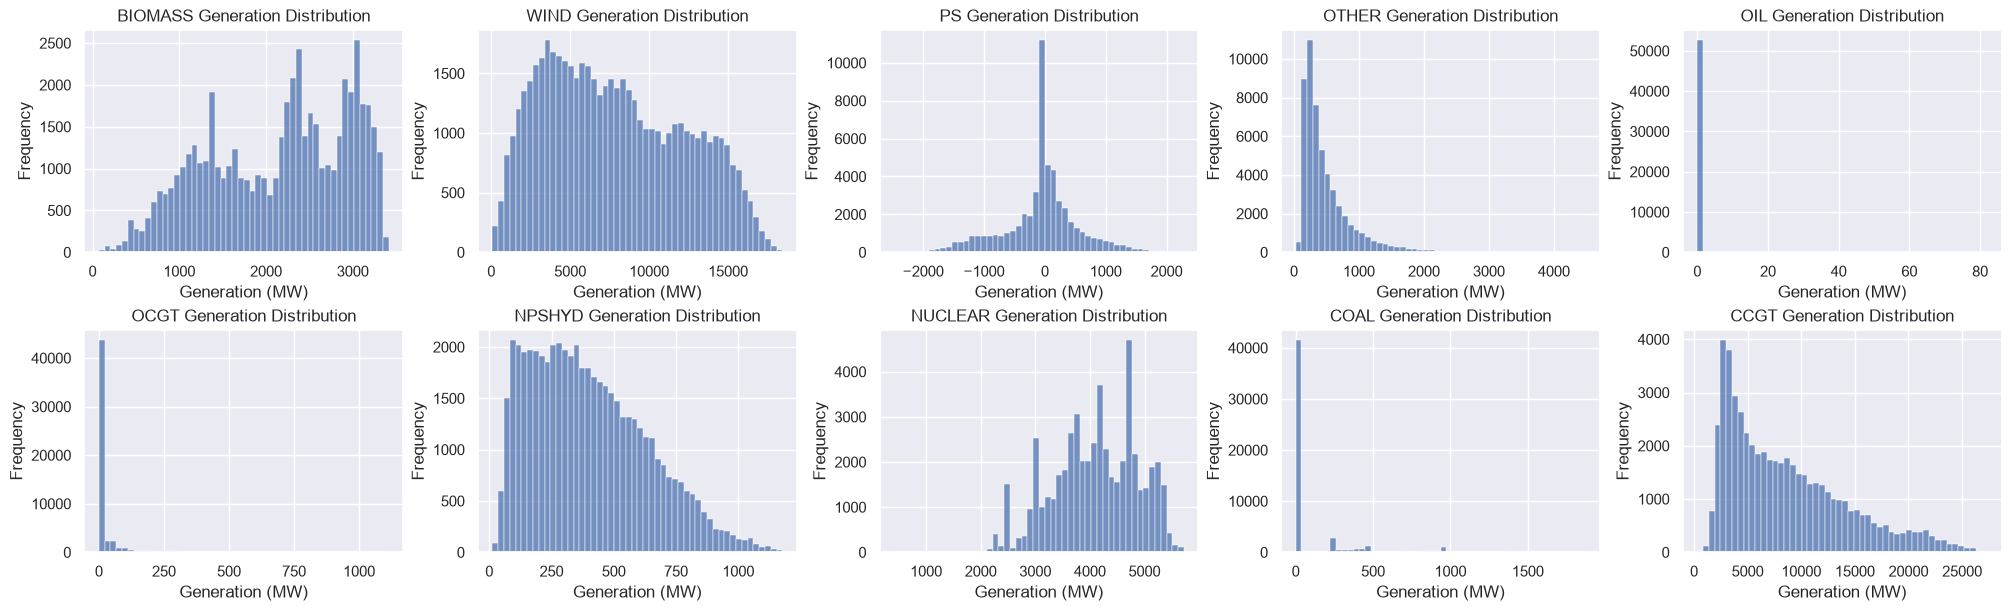

In [17]:
fig, axes = plt.subplots(2, 5, figsize = (20, 6), constrained_layout = True)
axes = axes.flatten()

for fuel, ax in zip(fuels, axes):
    sns.histplot(
        data = modelling,
        x = fuel,
        bins = 50,
        ax = ax
    )

    ax.set_title(f"{fuel} Generation Distribution")
    ax.set_xlabel("Generation (MW)")
    ax.set_ylabel("Frequency")

plt.show()

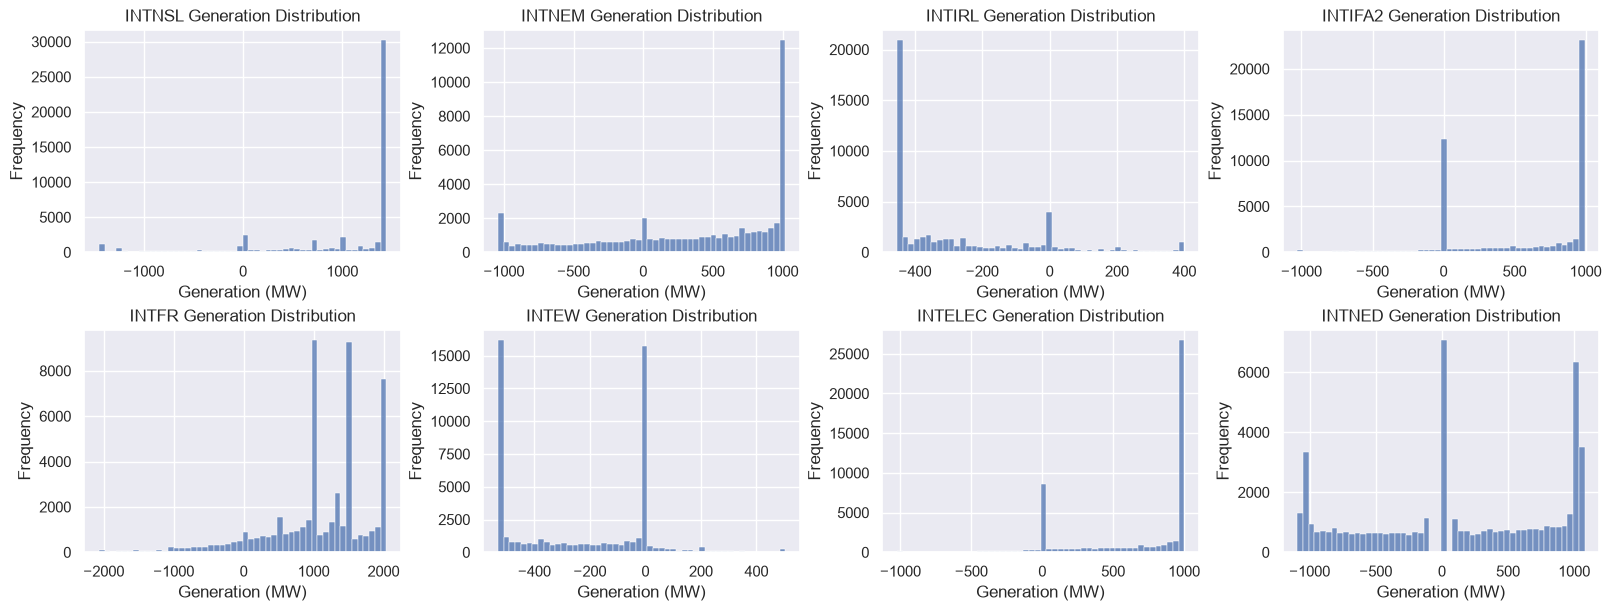

In [18]:
fig, axes = plt.subplots(2, 4, figsize = (16, 6), constrained_layout = True)
axes = axes.flatten()

for interconnector, ax in zip(interconnectors, axes):
    sns.histplot(
        data = modelling,
        x = interconnector,
        bins = 50,
        ax = ax
    )

    ax.set_title(f"{interconnector} Generation Distribution")
    ax.set_xlabel("Generation (MW)")
    ax.set_ylabel("Frequency")

plt.show()

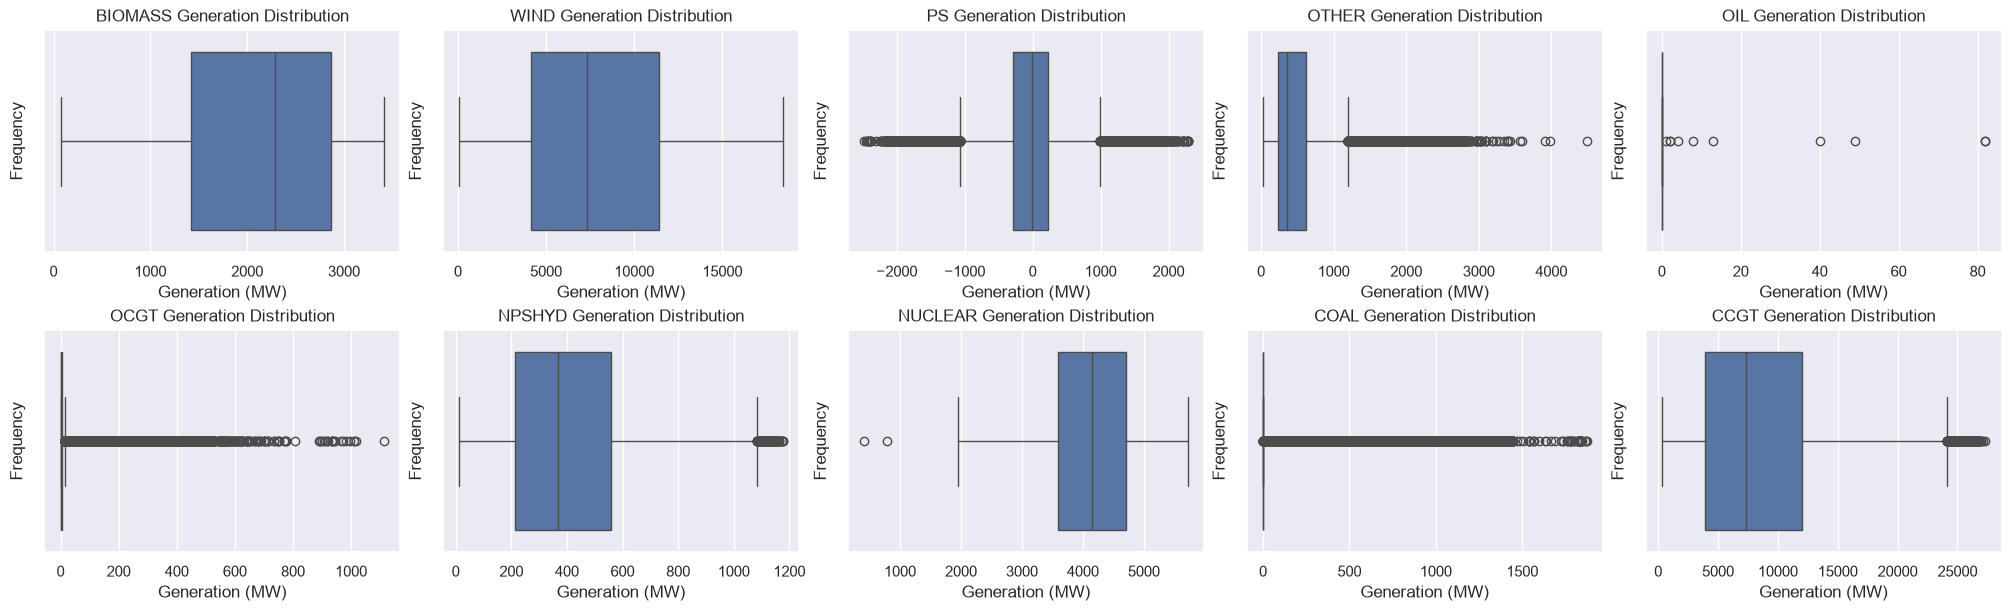

In [19]:
fig, axes = plt.subplots(2, 5, figsize = (20, 6), constrained_layout = True)
axes = axes.flatten()

for fuel, ax in zip(fuels, axes):
    sns.boxplot(
        data = modelling,
        x = fuel,
        ax = ax
    )

    ax.set_title(f"{fuel} Generation Distribution")
    ax.set_xlabel("Generation (MW)")
    ax.set_ylabel("Frequency")

plt.show()

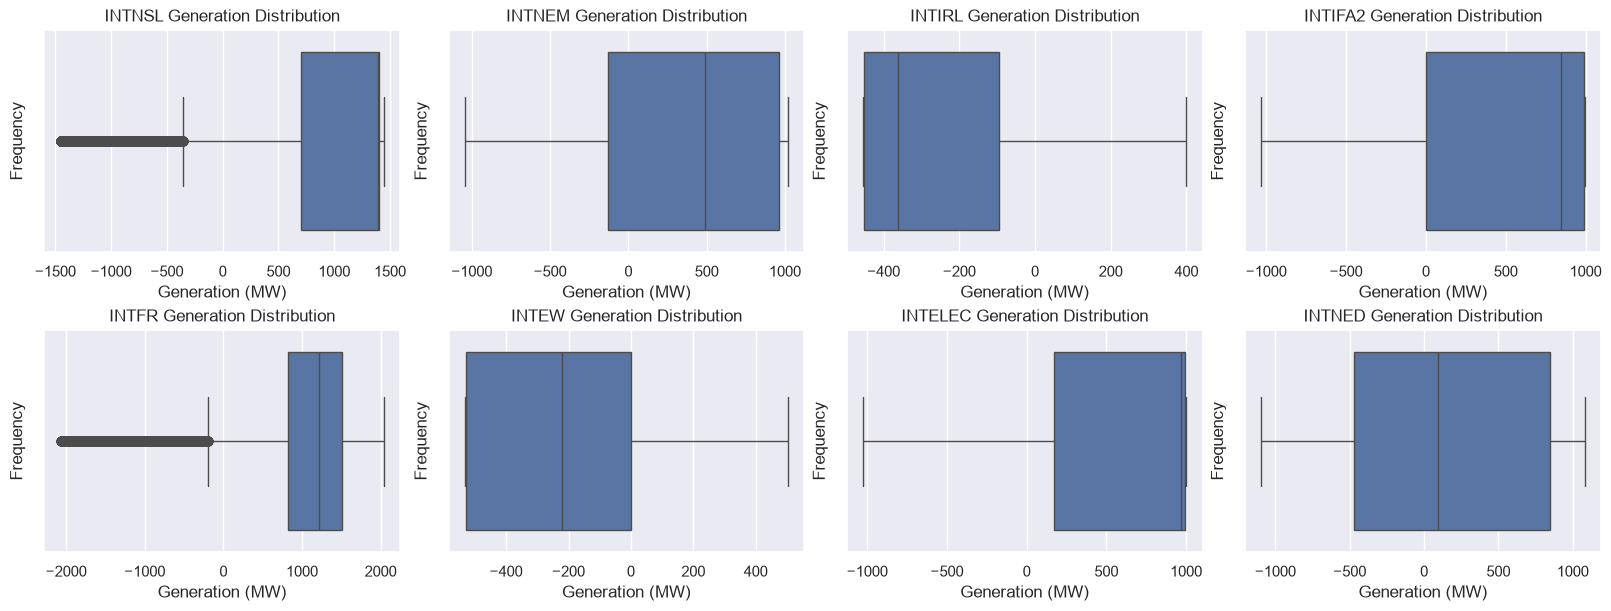

In [20]:
fig, axes = plt.subplots(2, 4, figsize = (16, 6), constrained_layout = True)
axes = axes.flatten()

for interconnector, ax in zip(interconnectors, axes):
    sns.boxplot(
        data = modelling,
        x = interconnector,
        ax = ax
    )

    ax.set_title(f"{interconnector} Generation Distribution")
    ax.set_xlabel("Generation (MW)")
    ax.set_ylabel("Frequency")

plt.show()

In [21]:
total_rows = modelling.shape[0]
no_oil = 100.0 * modelling[modelling["OIL"] == 0].shape[0] / total_rows
no_ocgt = 100.0 * modelling[modelling["OCGT"] == 0].shape[0] / total_rows
no_coal = 100.0 * modelling[modelling["COAL"] == 0].shape[0] / total_rows

print(f"NO OIL: {no_oil:.2f}%\nNO OCGT: {no_ocgt:.2f}%\nNO COAL: {no_coal:.2f}%")

NO OIL: 99.98%
NO OCGT: 33.25%
NO COAL: 78.48%


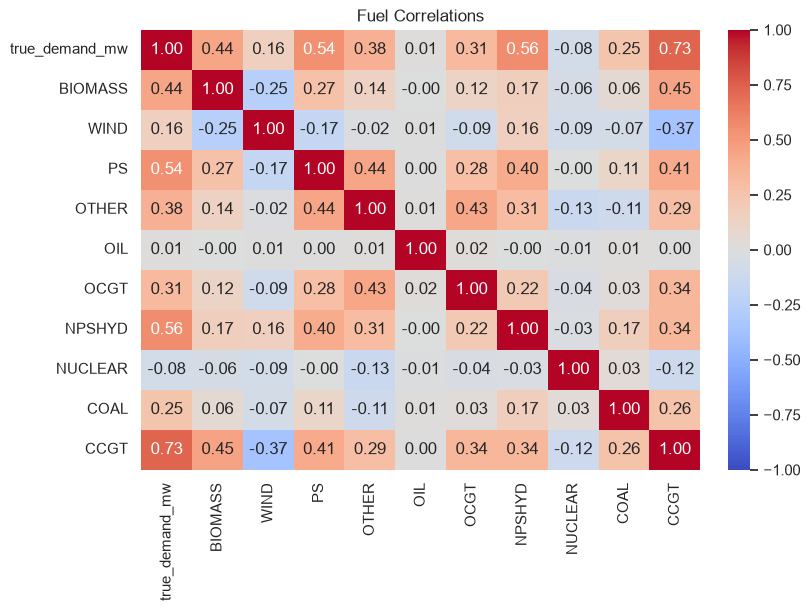

In [22]:
fuel_correlation = modelling[["true_demand_mw"] + fuels].corr()

plt.figure(figsize = (8, 6), constrained_layout = True)

sns.heatmap(
    data = fuel_correlation,
    vmin = -1,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f"
)

plt.title("Fuel Correlations")

plt.show()

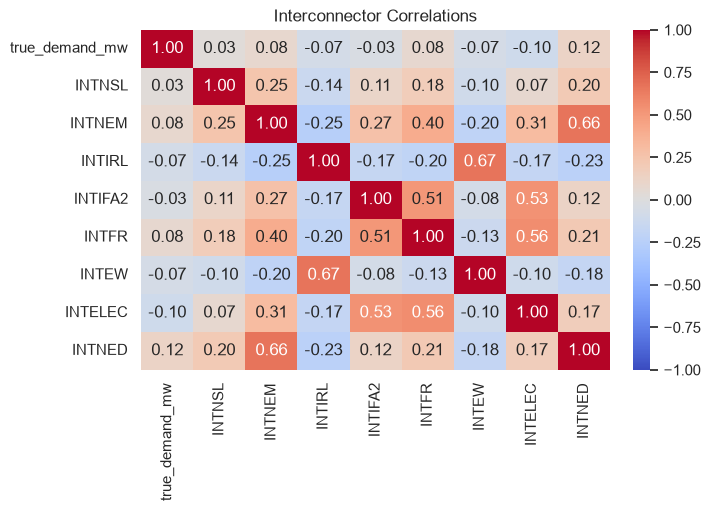

In [23]:
interconnector_correlation = modelling[["true_demand_mw"] + interconnectors].corr()

plt.figure(figsize = (7, 5), constrained_layout = True)

sns.heatmap(
    data = interconnector_correlation,
    vmin = -1,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f"
)

plt.title("Interconnector Correlations")

plt.show()

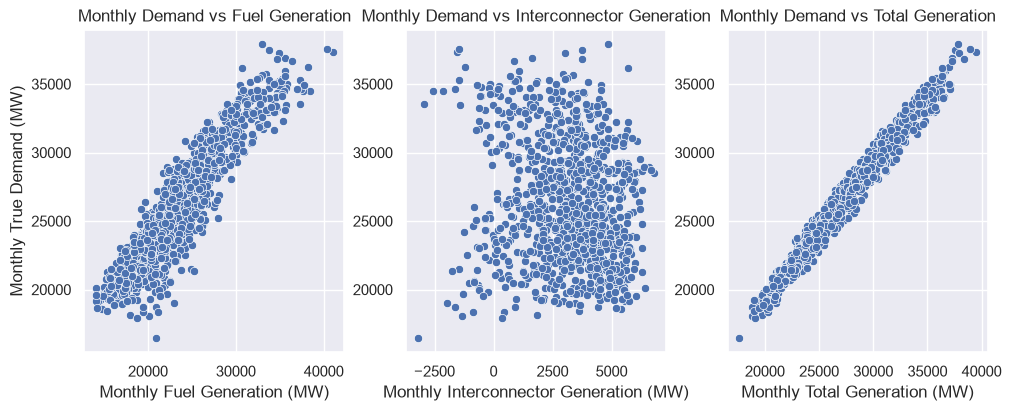

In [24]:
modelling["fuels_total"] = modelling[fuels].sum(axis = 1)
modelling["interconnectors_total"] = modelling[interconnectors].sum(axis = 1)
modelling["total_generation"] = modelling["fuels_total"] + modelling["interconnectors_total"]
to_plot = {
    "fuels_total": "Fuel",
    "interconnectors_total": "Interconnector",
    "total_generation": "Total"
}

daily_model = modelling.set_index("prediction_time").resample("D").agg({
    "true_demand_mw": "mean",
    "fuels_total": "mean",
    "interconnectors_total": "mean",
    "total_generation": "mean"
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize = (10, 4), constrained_layout = True)
axes = axes.flatten()

for (row, label), ax in zip(to_plot.items(), axes):
    sns.scatterplot(
        data = daily_model,
        x = row,
        y = "true_demand_mw",
        ax = ax
    )

    ax.set_title(f"Monthly Demand vs {label} Generation")
    ax.set_ylabel("")
    ax.set_xlabel(f"Monthly {label} Generation (MW)")

axes[0].set_ylabel("Monthly True Demand (MW)")

plt.show()

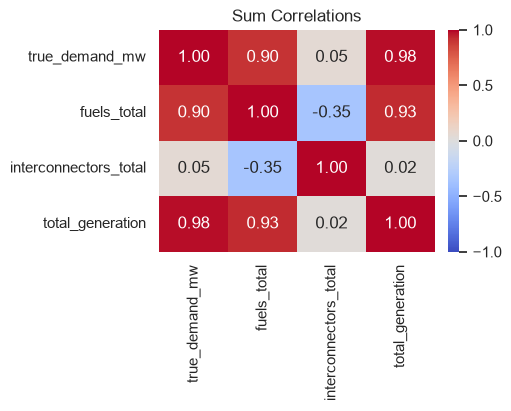

In [25]:
sums_correlation = modelling[["true_demand_mw"] + list(to_plot.keys())].corr()

plt.figure(figsize = (5, 4), constrained_layout = True)

sns.heatmap(
    data = sums_correlation,
    vmin = -1,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f"
)

plt.title("Sum Correlations")

plt.show()